# STAGE 10 — FAVOURABILITY-30 FIXED-RULE VISUAL COMPARISON

Диагностически сравниваем ровно пять заранее заданных правил на locked test. Threshold search, recalibration, winner selection и forecasting retraining отсутствуют. Lower rate = better.

In [1]:
from pathlib import Path
import sys
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.favourability30_visual_comparison import RULES,plot_all,run_visual_comparison
run=run_visual_comparison(ROOT,make_plots=False)
print('Locked-test rows:',len(run['frame']))
print('Fixed rules:',len(RULES))
print('Winner selection: NO')

Locked-test rows: 1375
Fixed rules: 5
Winner selection: NO


## 1. Summary table

Сигналы используют только `favourability_percentile_30`, `past_advantage_5`, `predicted_regret_5`. Hit rate относительно GT_30 является только диагностикой.

In [2]:
display(run['metrics'])

,corridor,rule,F,A,R,n_signals,signal_frequency,mean_signals_per_month,median_signals_per_month,months_with_zero_signals,hit_rate
0,AMD_RUB,RULE_1_STRICT,0.90,0.002,0.002,18,0.065455,1.285714,0.0,9,0.333333
1,AMD_RUB,RULE_2,0.90,0.000,0.005,28,0.101818,2.000000,0.5,7,0.392857
2,AMD_RUB,RULE_3_BALANCED,0.85,0.000,0.005,30,0.109091,2.142857,0.5,7,0.400000
3,AMD_RUB,RULE_4_SOFT,0.85,NaN,0.005,52,0.189091,3.714286,1.0,7,0.500000
4,AMD_RUB,RULE_5_BROAD,0.80,NaN,0.010,68,0.247273,4.857143,2.0,6,0.382353
5,KGS_RUB,RULE_1_STRICT,0.90,0.002,0.002,15,0.054545,1.071429,0.0,8,0.266667
6,KGS_RUB,RULE_2,0.90,0.000,0.005,32,0.116364,2.285714,0.5,7,0.312500
7,KGS_RUB,RULE_3_BALANCED,0.85,0.000,0.005,33,0.120000,2.357143,0.5,7,0.303030
8,KGS_RUB,RULE_4_SOFT,0.85,NaN,0.005,61,0.221818,4.357143,2.0,7,0.459016
9,KGS_RUB,RULE_5_BROAD,0.80,NaN,0.010,76,0.276364,5.428571,4.0,6,0.368421


## 2. 25 individual plots and 5 stacked comparisons

Внутри каждого corridor stacked panels имеют одинаковые x/y limits. Красные точки — сигналы фиксированного правила.

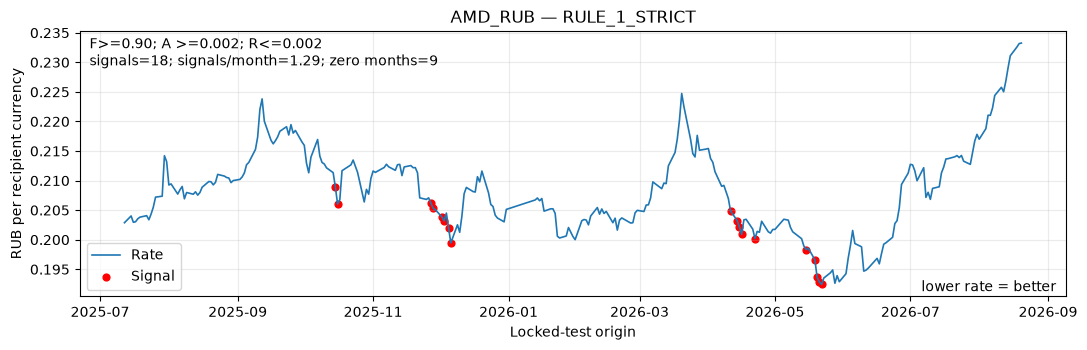

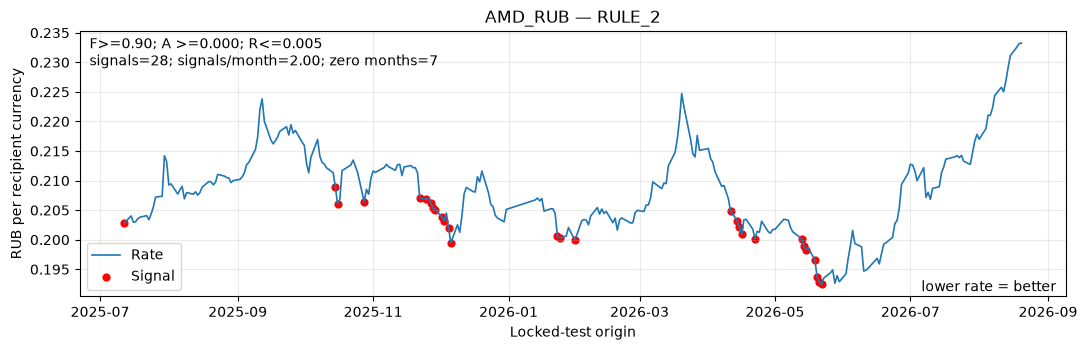

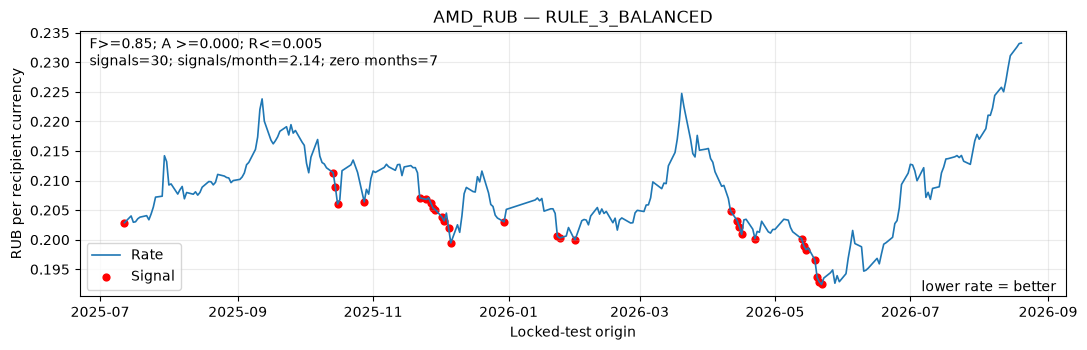

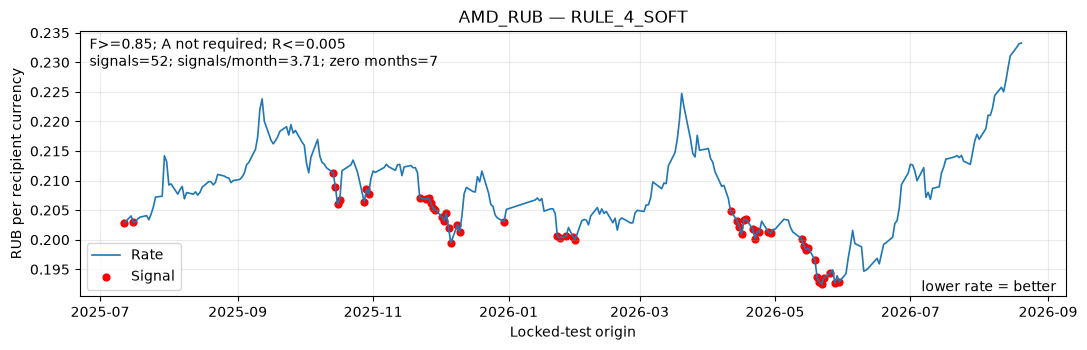

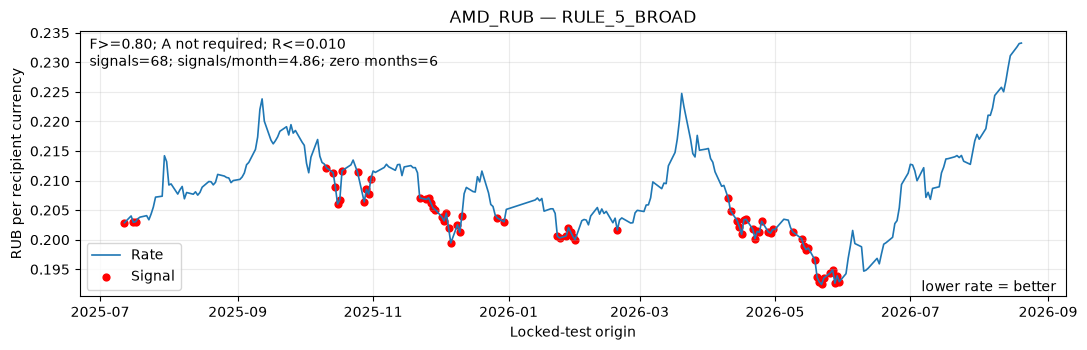

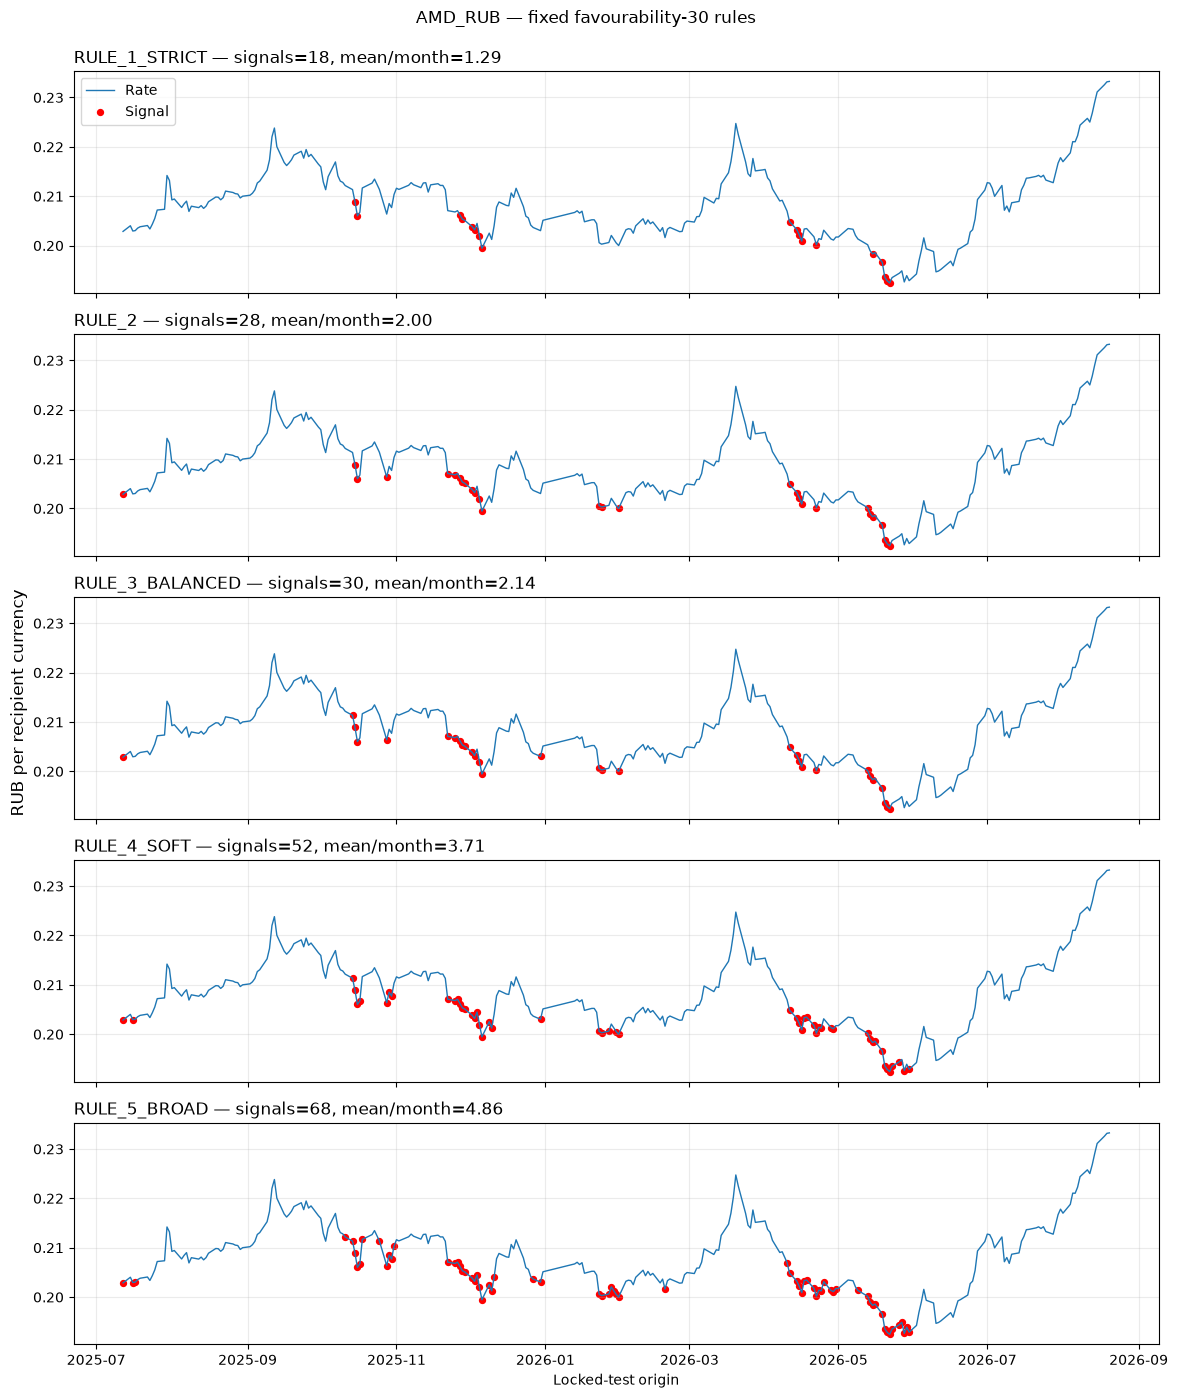

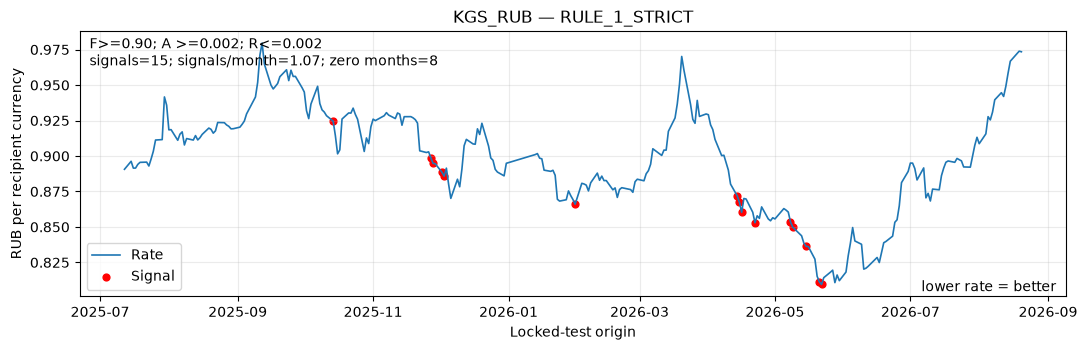

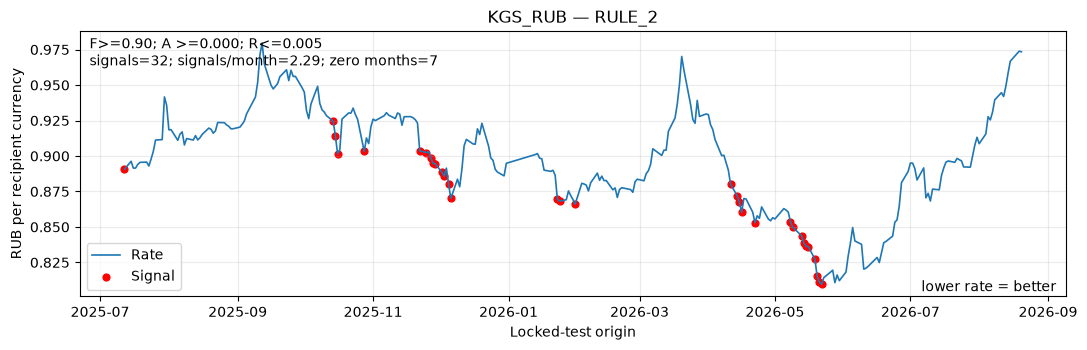

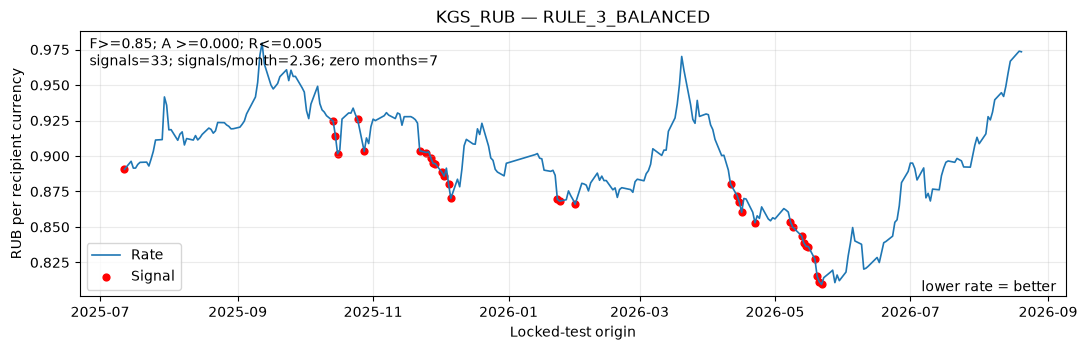

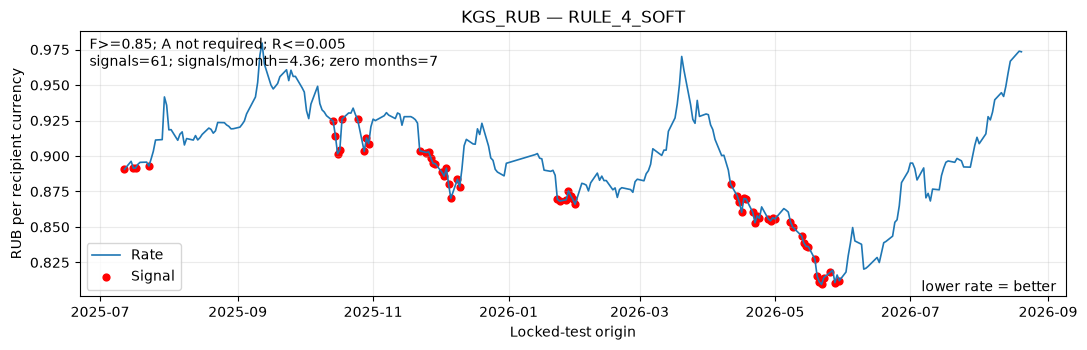

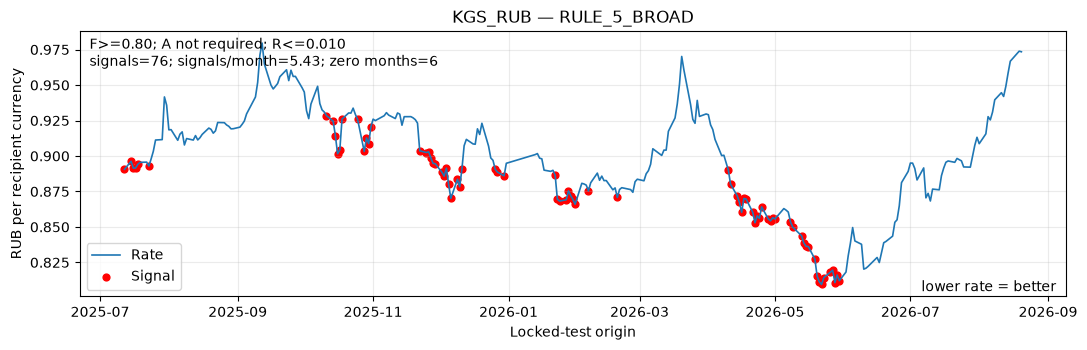

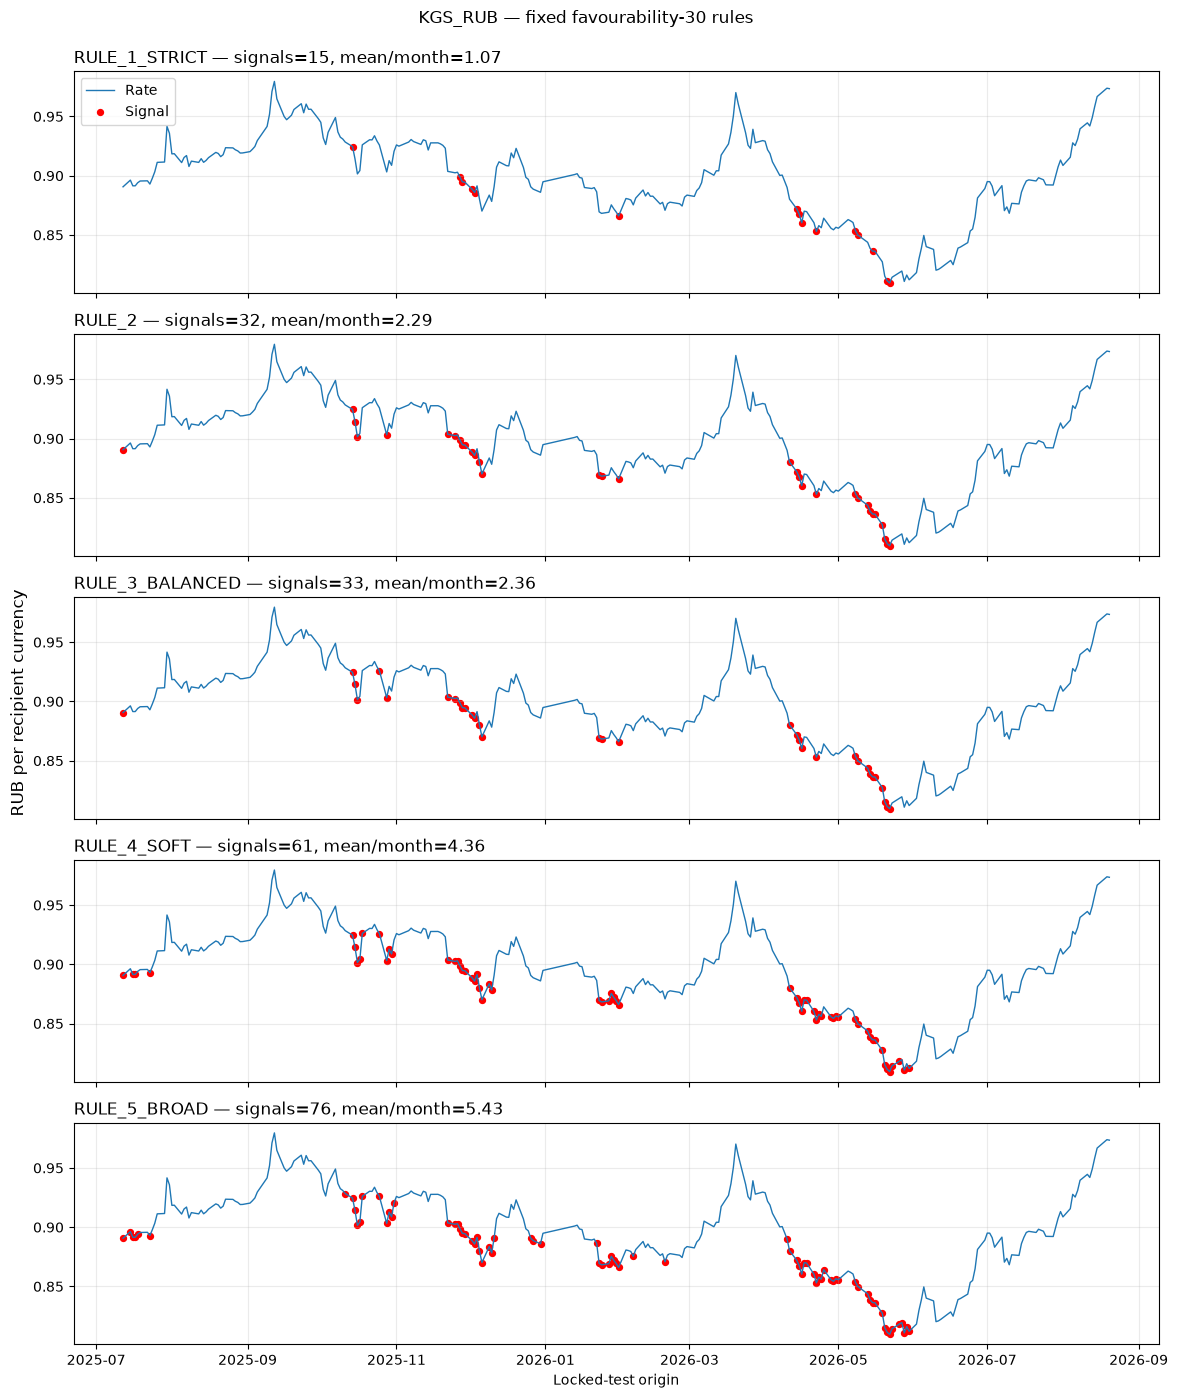

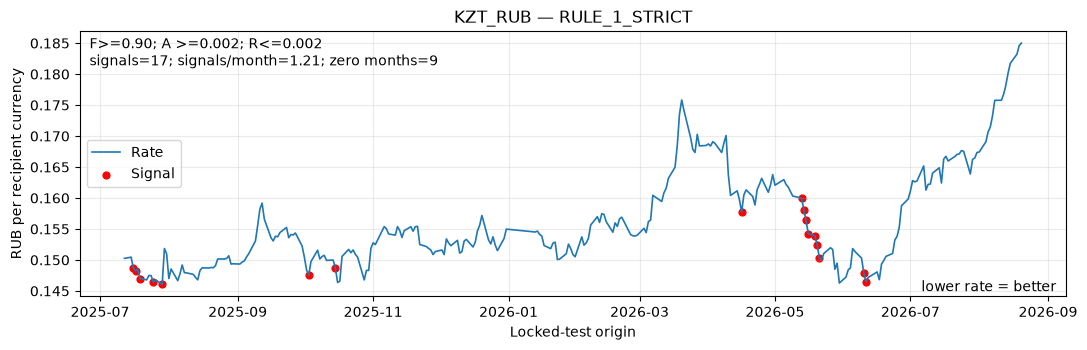

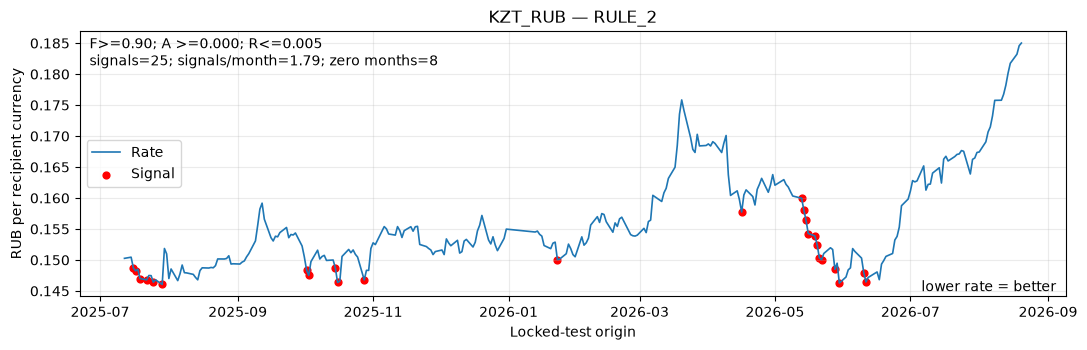

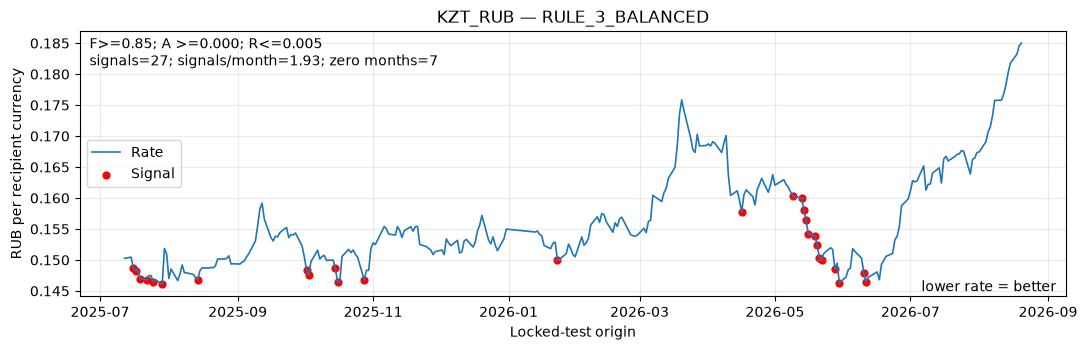

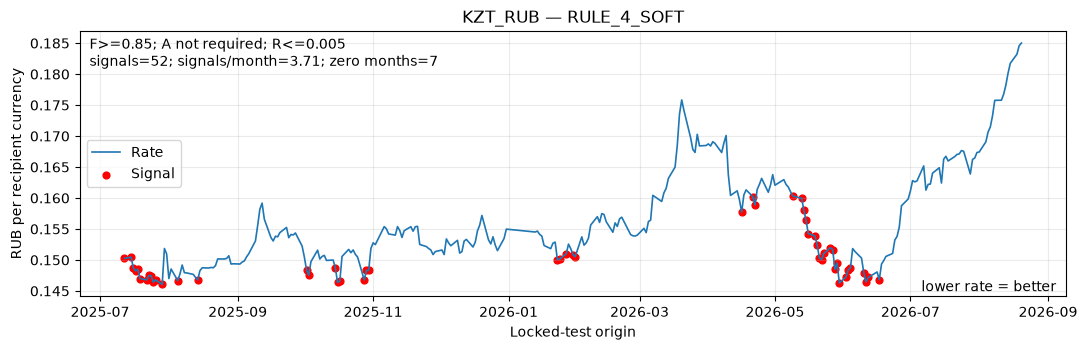

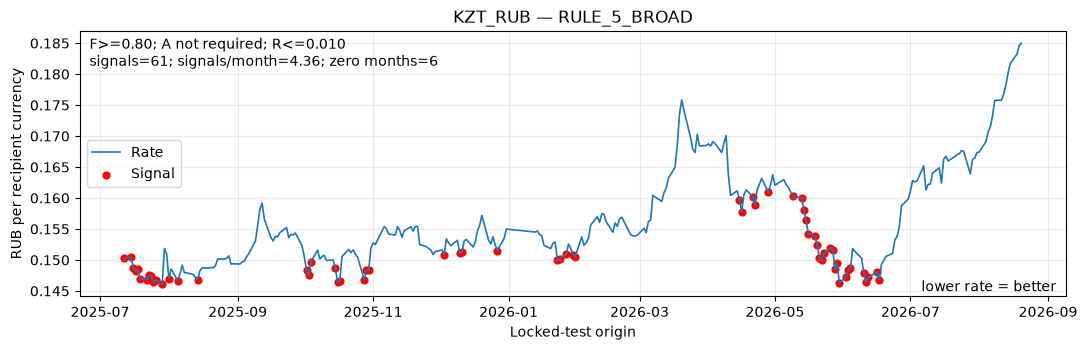

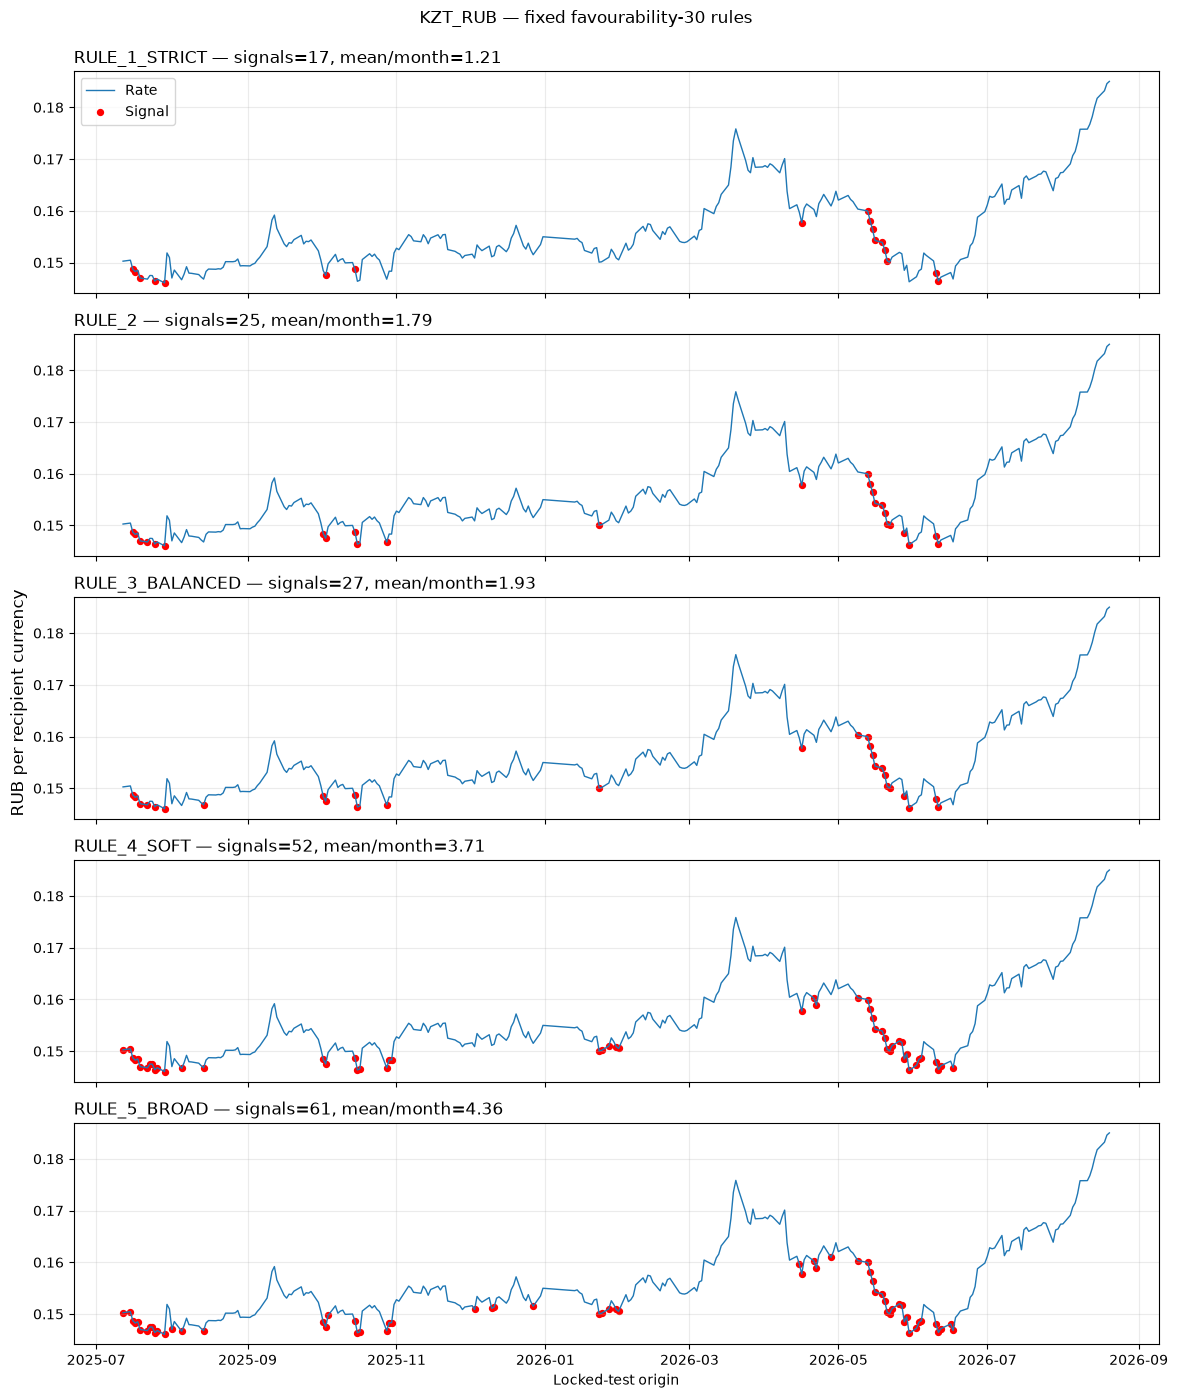

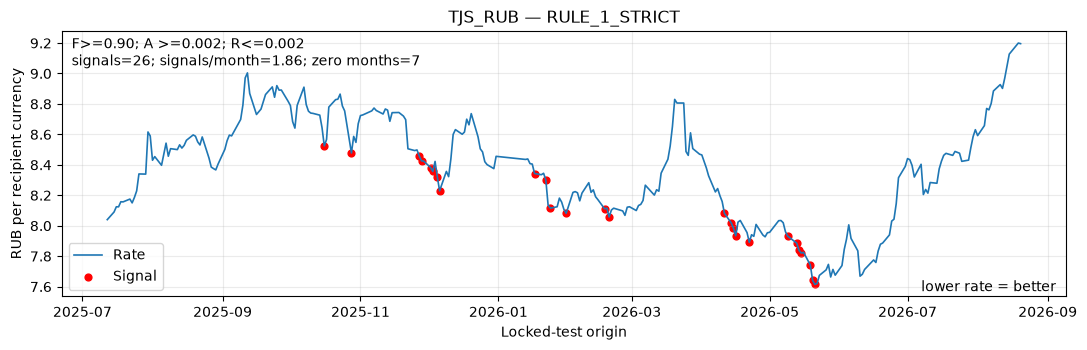

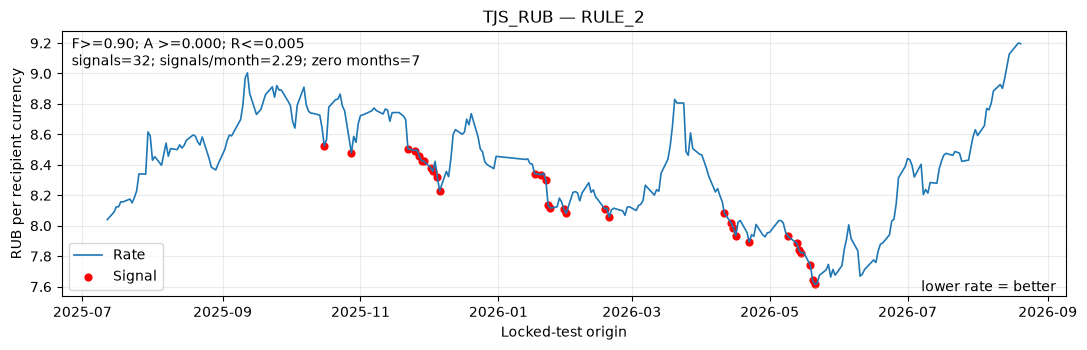

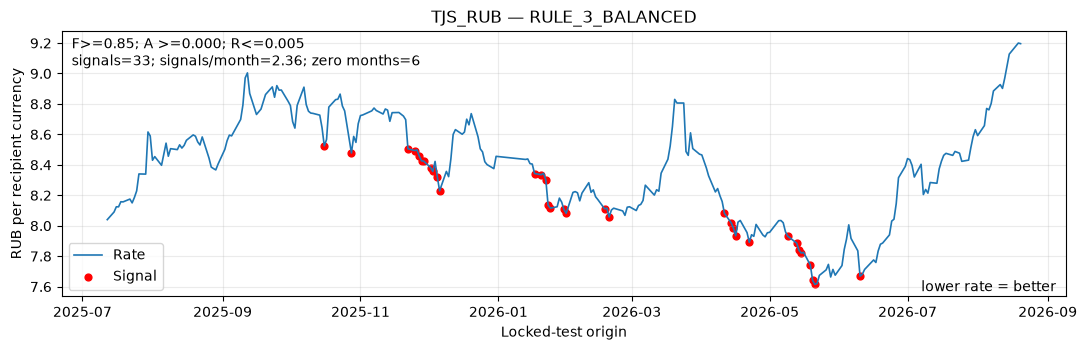

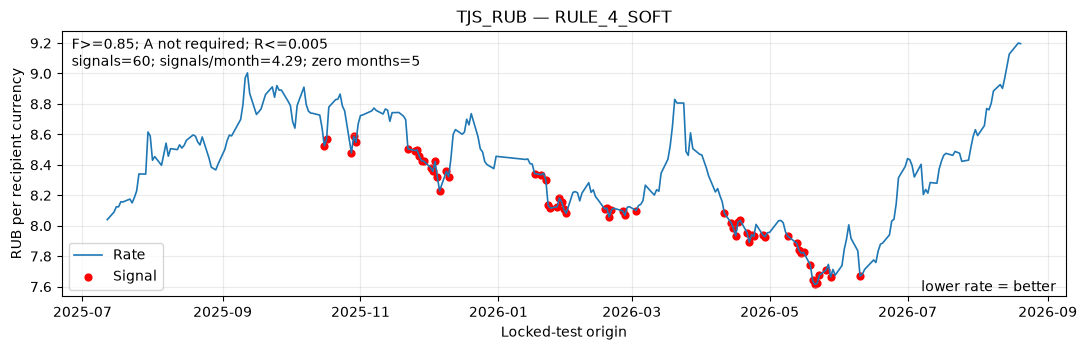

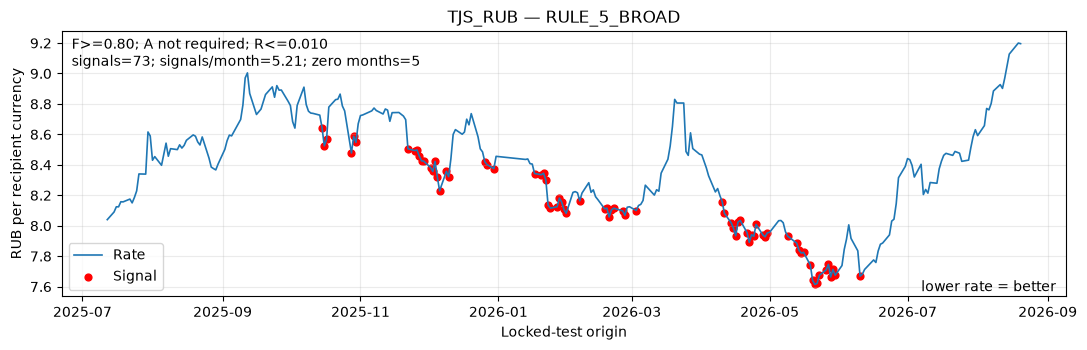

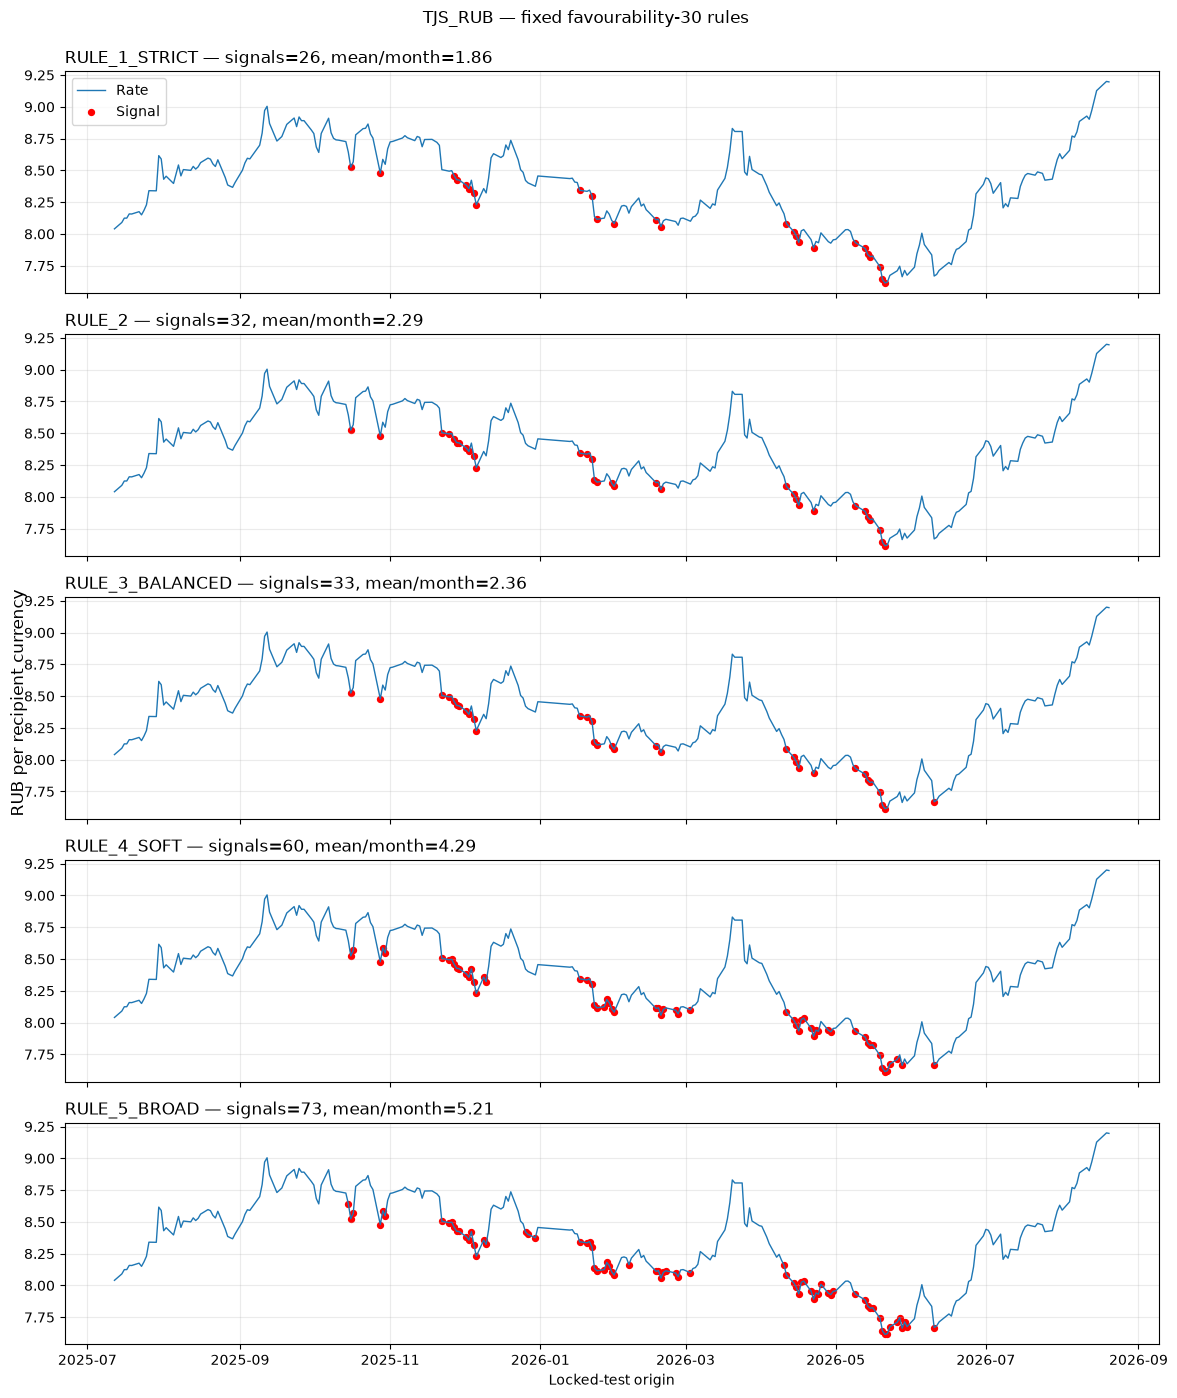

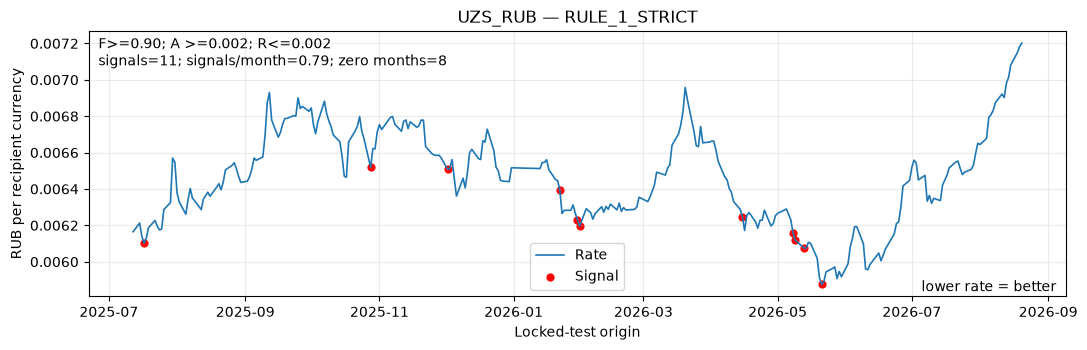

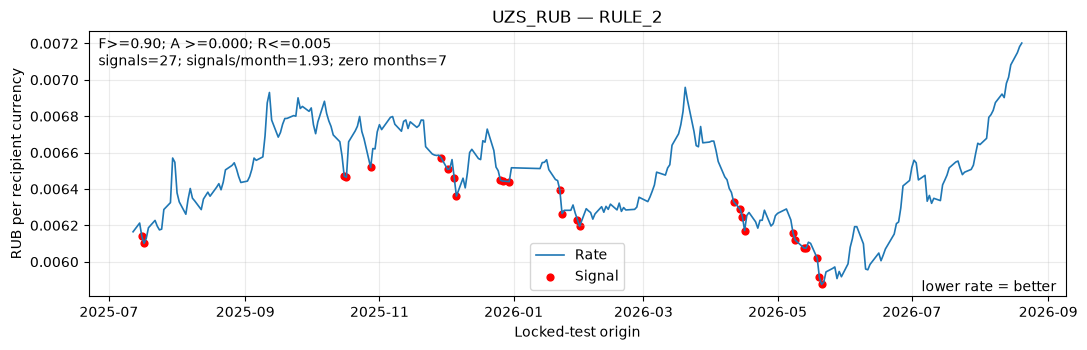

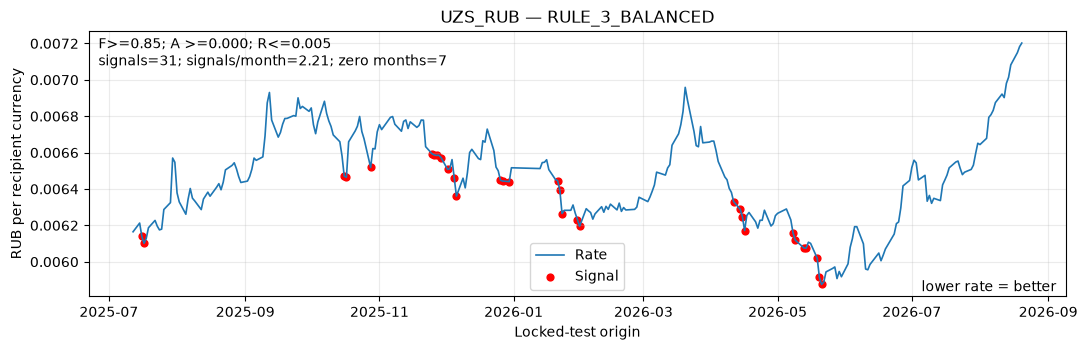

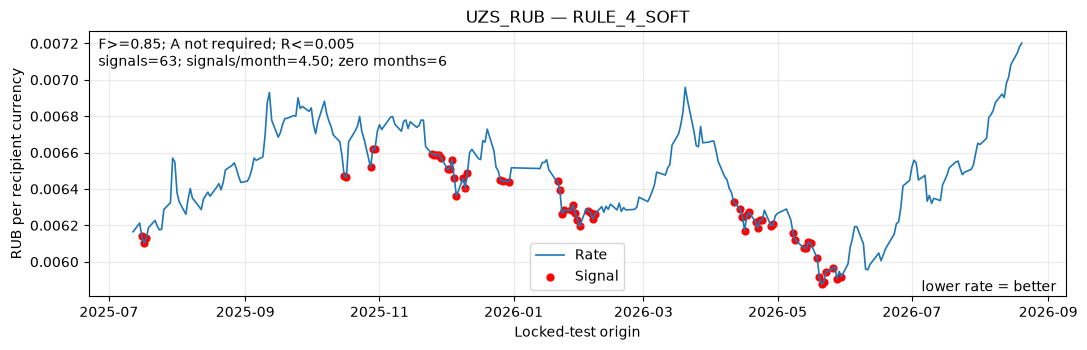

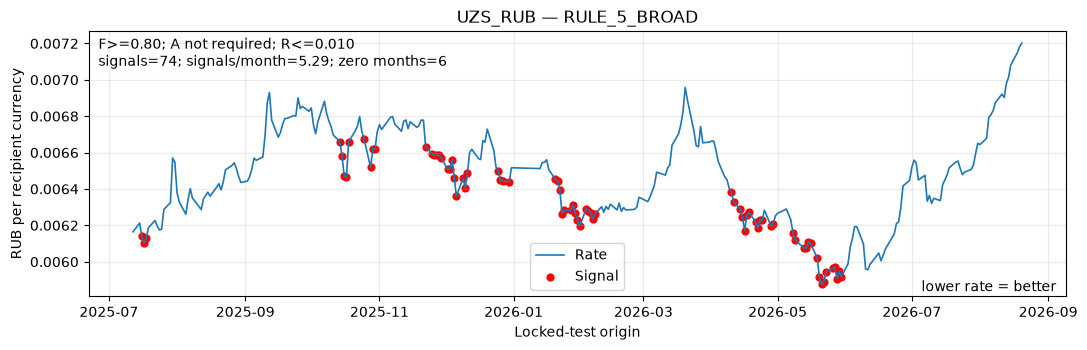

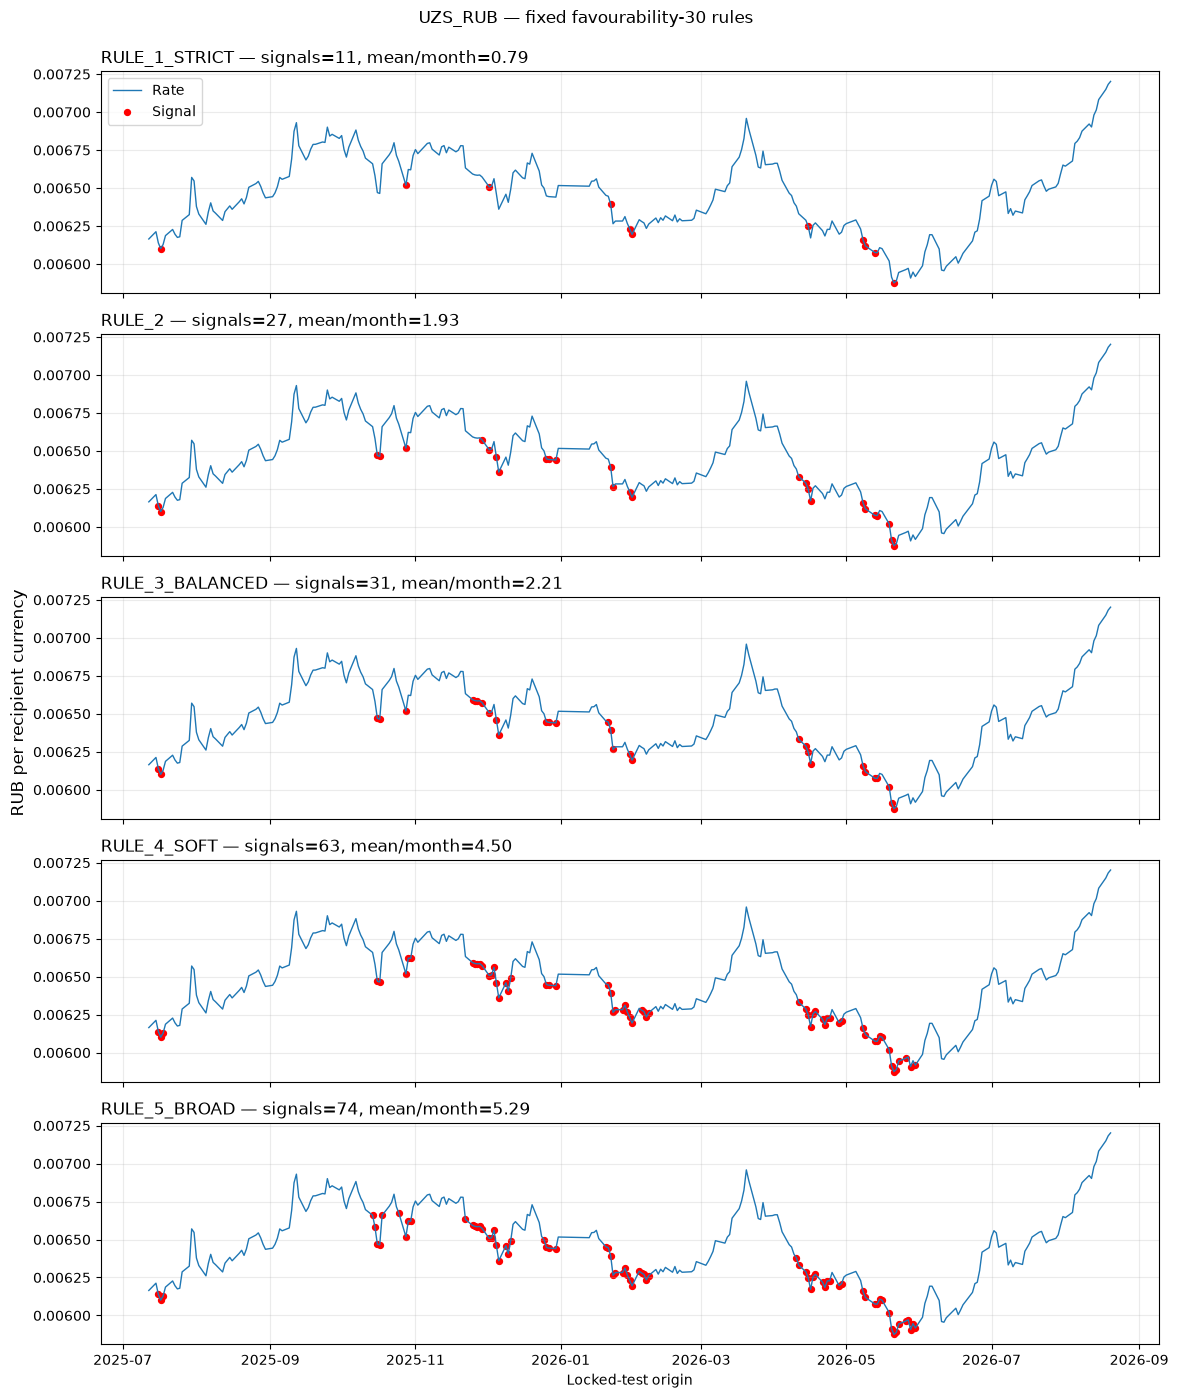

In [3]:
plot_all(run['frame'],run['metrics'],ROOT/'reports/figures/favourability30_rule_comparison')

## 3. Leakage note

In [4]:
display(run['leakage'])
check='PASS' if run['leakage'].passed.all() else 'FAIL'
print('RULE VISUAL COMPARISON CHECK:',check)

,check,passed
0,exactly five rules fixed in advance,True
1,signals use only approved live fields,True
2,no actual future rate in signals,True
3,actual_regret is diagnostic only,True
4,no winner or optimization,True


RULE VISUAL COMPARISON CHECK: PASS


## 4. Descriptive final summary

Лучшее правило не выбирается и автоматическая рекомендация не формируется.

In [5]:
display(run['metrics'].pivot(index='corridor',columns='rule',values=['n_signals','mean_signals_per_month']))
print('No best rule selected. No automatic recommendation produced.')
print('Output:',run['csv_path'].relative_to(ROOT))
print('Report:',run['report_path'].relative_to(ROOT))

n_signals                                                  \
rule     RULE_1_STRICT RULE_2 RULE_3_BALANCED RULE_4_SOFT RULE_5_BROAD   
corridor                                                                 
AMD_RUB           18.0   28.0            30.0        52.0         68.0   
KGS_RUB           15.0   32.0            33.0        61.0         76.0   
KZT_RUB           17.0   25.0            27.0        52.0         61.0   
TJS_RUB           26.0   32.0            33.0        60.0         73.0   
UZS_RUB           11.0   27.0            31.0        63.0         74.0   

         mean_signals_per_month                                        \
rule              RULE_1_STRICT    RULE_2 RULE_3_BALANCED RULE_4_SOFT   
corridor                                                                
AMD_RUB                1.285714  2.000000        2.142857    3.714286   
KGS_RUB                1.071429  2.285714        2.357143    4.357143   
KZT_RUB                1.214286  1.785714        1.928571    3.714286   
TJS_RUB                1.857143  2.285714        2.357143    4.285714   
UZS_RUB                0.785714  1.928571        2.214286    4.500000   

                       
rule     RULE_5_BROAD  
corridor               
AMD_RUB      4.857143  
KGS_RUB      5.428571  
KZT_RUB      4.357143  
TJS_RUB      5.214286  
UZS_RUB      5.285714

No best rule selected. No automatic recommendation produced.
Output: reports\favourability30_rule_visual_comparison.csv
Report: reports\favourability30_rule_visual_report.md
